## Stroke-Data

Atravéz de um SVM prever se a pessoa vai ter ou não um ataque cardiaco

Importação das bibliotecas

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns


In [2]:
df = pd.read_csv('../dataset/stroke-data.csv')
df.sample(10)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
1162,38804,Male,74.0,0,0,Yes,Private,Rural,83.50,26.7,Unknown,0
3821,56778,Male,64.0,1,0,Yes,Private,Urban,57.42,28.0,smokes,0
1528,11770,Female,25.0,0,0,Yes,Govt_job,Urban,93.23,NaN,smokes,0
4714,63467,Male,9.0,0,0,No,children,Urban,150.00,17.4,Unknown,0
176,62466,Female,80.0,0,0,Yes,Private,Urban,64.44,45.0,never smoked,1
3347,65508,Male,80.0,0,0,Yes,Govt_job,Urban,148.72,28.7,never smoked,0
4233,18352,Female,3.0,0,0,No,children,Rural,108.32,14.2,Unknown,0
2855,65196,Male,75.0,1,0,Yes,Private,Rural,198.79,NaN,smokes,0
1124,59940,Male,15.0,0,0,No,children,Urban,116.50,27.8,Unknown,0
1440,57137,Male,65.0,0,0,Yes,Private,Urban,59.87,28.5,smokes,0


Valores em Falta

In [3]:
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [5]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


Visualização das relaçoes, correlaçoes e da separabilidade entre classes

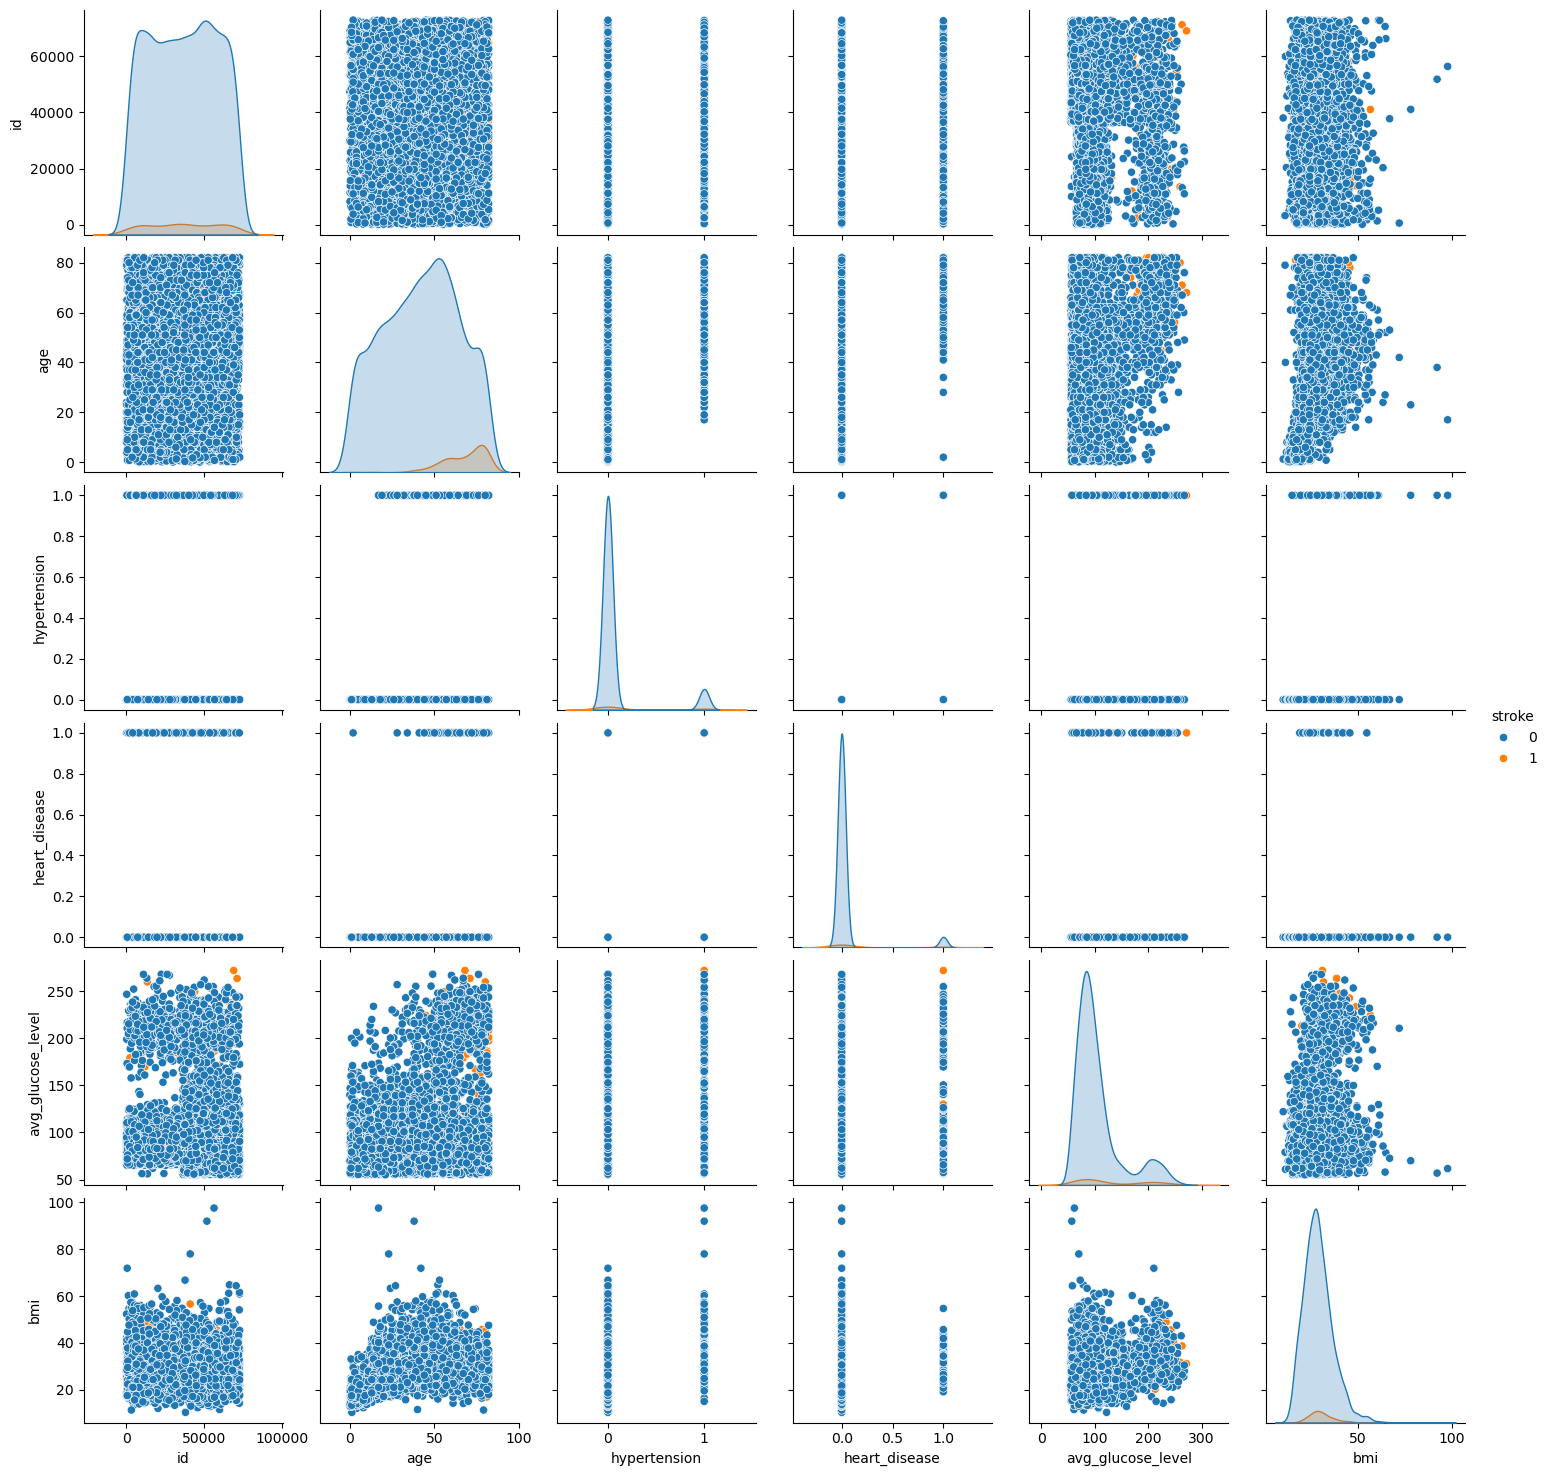

In [6]:
sns.pairplot(df, hue='stroke')

Pre-processamento 

In [9]:
from sklearn.preprocessing import OneHotEncoder # importação da classe OneHotEncoder para codificação de variáveis categóricas
encoder = OneHotEncoder(sparse_output=False)

average_bmi = df.groupby('gender')['bmi'].mean() #calculo medio do bmi
for gender, bmi in average_bmi.items(): ## substituir o for pot fillna
    df.loc[(df['gender'] == gender) & (df['bmi'].isnull()), 'bmi'] = bmi # prenchimento de valores em falta com a media do bmi por genero

cols_to_encode = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status'] # colunas a codificar
encoded_data = encoder.fit_transform(df[cols_to_encode])
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(cols_to_encode),index=df.index) # criação dataframe com os dados codificados
df = pd.concat([df, encoded_df], axis=1)
df.drop(columns = cols_to_encode, inplace=True) # remoção das colunas originais
df.drop(columns=['id'], inplace=True)
df.info()
df.isnull().sum() #valores em falta


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 38 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             5110 non-null   float64
 1   hypertension                    5110 non-null   int64  
 2   heart_disease                   5110 non-null   int64  
 3   avg_glucose_level               5110 non-null   float64
 4   bmi                             5110 non-null   float64
 5   stroke                          5110 non-null   int64  
 6   gender_Female                   5110 non-null   float64
 7   gender_Male                     5110 non-null   float64
 8   gender_Other                    5110 non-null   float64
 9   ever_married_No                 5110 non-null   float64
 10  ever_married_Yes                5110 non-null   float64
 11  work_type_Govt_job              5110 non-null   float64
 12  work_type_Never_worked          51

age                               0
hypertension                      0
heart_disease                     0
avg_glucose_level                 0
bmi                               0
stroke                            0
gender_Female                     0
gender_Male                       0
gender_Other                      0
ever_married_No                   0
ever_married_Yes                  0
work_type_Govt_job                0
work_type_Never_worked            0
work_type_Private                 0
work_type_Self-employed           0
work_type_children                0
Residence_type_Rural              0
Residence_type_Urban              0
smoking_status_Unknown            0
smoking_status_formerly smoked    0
smoking_status_never smoked       0
smoking_status_smokes             0
gender_Female                     0
gender_Male                       0
gender_Other                      0
ever_married_No                   0
ever_married_Yes                  0
work_type_Govt_job          

Treinar com SVM


In [10]:
# Separate features and target
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV
scaler = StandardScaler()

from sklearn.model_selection import train_test_split # separação dos dados em treino e teste
X = df.drop(columns=['stroke'])
y = df['stroke']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

smote = SMOTE(random_state=42) # Aplicar SMOTE no conjunto de treino 
X_train, y_train = smote.fit_resample(X_train, y_train)

from sklearn import svm # import do SVM para classificação
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)


param_distributions = {  # hiperparâmetros a testar
    'C': [0.01, 0.1, 1, 10, 100],
    'kernel': ['rbf', 'linear', 'poly'],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'class_weight': [None, 'balanced', {0: 1, 1: 5}, {0: 1, 1: 10}]
}

search = RandomizedSearchCV(   # pesquisa aleatória de hiperparâmetros para o modelo SVM
    svm.SVC(class_weight='balanced', random_state=42),
    param_distributions=param_distributions,
    n_iter=20,
    scoring='f1',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)  # ajuste do modelo SVM com os melhores hiperparâmetros encontrados

print(search.best_params_)  
best_clf = search.best_estimator_
y_pred = best_clf.predict(X_test)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
{'kernel': 'poly', 'gamma': 0.1, 'class_weight': 'balanced', 'C': 100}
